**Model & notation**

Let $X \in \mathbb{R}^{n\times p}$, $y \in \mathbb{R}^{n}$, $\beta \in \mathbb{R}^{p}$.
(Include a column of ones in $X$ if you want an intercept.)

$$
y = X\beta + \epsilon
$$

**Objective (OLS)**

Minimize the sum of squared residuals (scaled by $\frac{1}{2n}$ for convenience):

$$
J(\beta) = \frac{1}{2n}\,\lVert y - X\beta \rVert_2^2
$$

**Gradient**

Using $\nabla_\beta \lVert y - X\beta \rVert_2^2 = -2X^\mathsf{T}(y - X\beta)$:

$$
\nabla_\beta J(\beta) = -\frac{1}{n}X^\mathsf{T}(y - X\beta)
= \frac{1}{n}\big(X^\mathsf{T}X\,\beta - X^\mathsf{T}y\big)
$$

**Normal equations (set gradient to zero)**

$$
X^\mathsf{T}X\,\hat{\beta} = X^\mathsf{T}y
$$

**Closed-form solution (when $X^\mathsf{T}X$ is invertible)**

$$
\hat{\beta} = (X^\mathsf{T}X)^{-1}X^\mathsf{T}y
$$

**Predictions**

$$
\hat{y} = X\hat{\beta}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

1d example

In [2]:
# 1) Generate synthetic data: y = 3 + 2x + noise
rng = np.random.default_rng(0)
n = 60
x = np.linspace(0, 10, n)
noise = rng.normal(0, 1.0, size=n)
y = 3 + 2 * x + noise

In [3]:
# 2) Build design matrices
X_with_intercept = np.column_stack([np.ones(n), x])   # column of 1s + x
X_no_intercept = x.reshape(-1, 1)                      # just x

In [4]:
# 3) Solve normal equations: (X^T X) beta = X^T y
def normal_eq_solution(X, y):
    XtX = X.T @ X
    Xty = X.T @ y
    beta = np.linalg.solve(XtX, Xty)  # solve instead of explicit inverse
    return beta, XtX, Xty

beta_with, XtX_with, Xty_with = normal_eq_solution(X_with_intercept, y)
beta_no, XtX_no, Xty_no = normal_eq_solution(X_no_intercept, y)


In [5]:
# 4) Predictions and RSS
yhat_with = X_with_intercept @ beta_with
yhat_no = X_no_intercept @ beta_no

rss_with = np.sum((y - yhat_with) ** 2)
rss_no = np.sum((y - yhat_no) ** 2)

In [6]:
# 5) Print results
print("=== WITH intercept (column of 1s) ===")
print("X^T X:\n", XtX_with)
print("X^T y:\n", Xty_with)
print("beta (intercept, slope):", beta_with)
print("RSS:", rss_with)
print()

print("=== NO intercept (forced through origin) ===")
print("X^T X:\n", XtX_no)
print("X^T y:\n", Xty_no)
print("beta (slope only):", beta_no)
print("RSS:", rss_no)

=== WITH intercept (column of 1s) ===
X^T X:
 [[  60.          300.        ]
 [ 300.         2016.94915254]]
X^T y:
 [ 784.6377526  4985.35235354]
beta (intercept, slope): [2.80391033 2.05467711]
RSS: 46.78006769340146

=== NO intercept (forced through origin) ===
X^T X:
 [[2016.94915254]]
X^T y:
 [4985.35235354]
beta (slope only): [2.47172932]
RSS: 167.68175704557447


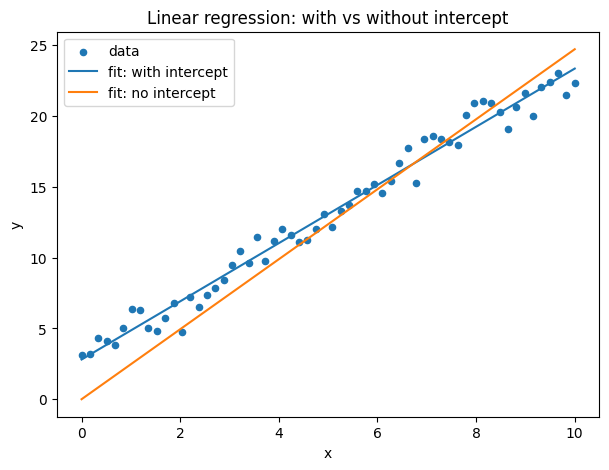

In [7]:
# 6) Plot data and fitted lines (single chart, no custom colors/styles)
plt.figure(figsize=(7,5))
plt.scatter(x, y, label="data", s=20)
# For clean lines, evaluate on a dense grid
xx = np.linspace(x.min(), x.max(), 200)
yy_with = beta_with[0] + beta_with[1] * xx
yy_no = beta_no[0] * xx  # slope only
plt.plot(xx, yy_with, label="fit: with intercept")
plt.plot(xx, yy_no, label="fit: no intercept")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression: with vs without intercept")
plt.legend()
plt.show()

nd example

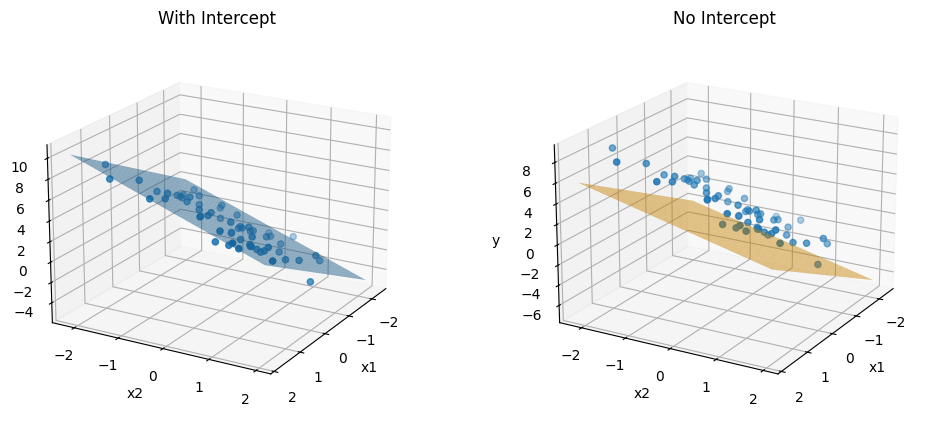

=== WITH intercept ===
beta: [ 2.98348054  1.9988616  -1.60842399]
=== NO intercept ===
beta: [ 1.91906854 -1.08243032]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
n = 60   # number of observations
d = 2    # number of features for 3D visualization

# Random feature matrix (n x d)
rng = np.random.default_rng(0)
X_features = rng.normal(size=(n, d))

# True coefficients (including intercept)
beta_true = np.array([3.0, 2.0, -1.5])  # intercept + slopes

# Generate y = β0 + β1*x1 + β2*x2 + noise
y = beta_true[0] + X_features @ beta_true[1:] + rng.normal(0, 0.5, size=n)

# Build design matrices
X_with_intercept = np.column_stack([np.ones(n), X_features])
X_no_intercept = X_features

# Normal equation solver
def normal_eq_solution(X, y):
    XtX = X.T @ X
    Xty = X.T @ y
    beta = np.linalg.solve(XtX, Xty)
    return beta, XtX, Xty

# Fit models
beta_with, XtX_with, Xty_with = normal_eq_solution(X_with_intercept, y)
beta_no, XtX_no, Xty_no = normal_eq_solution(X_no_intercept, y)

# Predictions
yhat_with = X_with_intercept @ beta_with
yhat_no = X_no_intercept @ beta_no

# Create a grid for plotting fitted plane (with intercept)
x1_grid, x2_grid = np.meshgrid(
    np.linspace(X_features[:,0].min(), X_features[:,0].max(), 30),
    np.linspace(X_features[:,1].min(), X_features[:,1].max(), 30)
)
y_grid_with = beta_with[0] + beta_with[1] * x1_grid + beta_with[2] * x2_grid
y_grid_no = beta_no[0] * x1_grid + beta_no[1] * x2_grid

# Plot data and fitted planes
fig = plt.figure(figsize=(12,5))

# With intercept
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_features[:,0], X_features[:,1], y, label="Data", s=20)
ax1.plot_surface(x1_grid, x2_grid, y_grid_with, alpha=0.5)
ax1.set_title("With Intercept")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("y")
ax1.view_init(elev=20, azim=30)

# No intercept
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_features[:,0], X_features[:,1], y, label="Data", s=20)
ax2.plot_surface(x1_grid, x2_grid, y_grid_no, alpha=0.5, color="orange")
ax2.set_title("No Intercept")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("y")
ax2.view_init(elev=20, azim=30)

plt.show()

# Print results
print("=== WITH intercept ===")
print("beta:", beta_with)

print("=== NO intercept ===")
print("beta:", beta_no)
